In [34]:
#Import all packages
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import folium
import contextily as ctx
import scipy.stats
import scipy.interpolate
import tqdm
from pathlib import Path
import xarray as xr
import skgstat as skg
import seaborn as sns
import pysal
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import moran_scatterplot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.plot import show
import rasterio
import xarray as xr
import numpy as np
from pathlib import Path
import re
from datetime import datetime
import geopandas as gpd
import re
from datetime import datetime
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from rasterio.features import rasterize
from shapely.geometry import mapping

In [35]:
#Summon the Data
DATA = Path("/home/jovyan/Society_of_Bouy_Cowboys/Data")

NETCDF = DATA / "NET_CDF"
ICE = DATA / "Ice_edge"
SAT = DATA / "SAT_GeoTiff"

# buoy files
moor_files = {
    "S1P1": NETCDF / "S1P1.nc",
    "S1P2": NETCDF / "S1P2.nc",
    "S1P3": NETCDF / "S1P3.nc",
    "S1A1": NETCDF / "S1A1.nc"
}



In [36]:
#Create XArray for all GeoTiffs with Ice Edge

# Load all GeoTIFFs into a single xarray Dataset with a time dimension
scenes = {}
for tif_path in sorted(SAT.glob("*.tif")):
    m = re.search(r"_(\d{8})(\d{4})_", tif_path.stem)
    if m:
        t = datetime.strptime(m.group(1) + m.group(2), "%Y%m%d%H%M")
    else:
        continue
    with rasterio.open(tif_path) as src:
        scenes[t] = {
            "sigma0":    src.read(1),
            "png":       src.read(2),
            "bounds":    src.bounds,
            "transform": src.transform,
            "shape":     (src.height, src.width),
        }

# Parse datetime from filename e.g. ice_edge_201911260350.geojson
ice_edges = {}
for geojson_path in sorted(ICE.glob("*.geojson")):
    m = re.search(r"_(\d{8})(\d{4})", geojson_path.stem)
    if m:
        t = datetime.strptime(m.group(1) + m.group(2), "%Y%m%d%H%M")
        ice_edges[t] = gpd.read_file(geojson_path).to_crs("EPSG:32604")

print(f"Loaded {len(scenes)} SAR scenes")
print(f"Loaded {len(ice_edges)} ice edge files")

# ── Sort by time ───────────────────────────────────────────────────────────
times  = sorted(scenes.keys())
bounds = scenes[times[0]]["bounds"]
shape  = scenes[times[0]]["shape"]

# ── Rasterize ice edges onto the SAR grid ──────────────────────────────────
# For each SAR scene, if a matching ice edge exists (within 1 hour),
# burn it into a binary raster (1 = ice edge, 0 = no data).
# If no ice edge exists for that scene, fill with NaN.

def find_nearest_edge(t, ice_edges, max_hours=1):
    """Return the ice edge GeoDataFrame closest in time to t, within max_hours."""
    best_t, best_dt = None, None
    for et in ice_edges:
        dt = abs((t - et).total_seconds()) / 3600
        if dt <= max_hours and (best_dt is None or dt < best_dt):
            best_t, best_dt = et, dt
    return ice_edges[best_t] if best_t else None

ice_rasters = []
for t in times:
    edge_gdf = find_nearest_edge(t, ice_edges, max_hours=1)
    if edge_gdf is not None and len(edge_gdf) > 0:
        # Burn the line geometry into the raster grid
        burned = rasterize(
            [(mapping(geom), 1) for geom in edge_gdf.geometry],
            out_shape = shape,
            transform = scenes[t]["transform"],
            fill      = 0,
            dtype     = np.float32,
        )
    else:
        burned = np.full(shape, np.nan, dtype=np.float32)
    ice_rasters.append(burned)

print(f"Ice edge rasters built: {sum(np.any(r == 1) for r in ice_rasters)}/{len(times)} scenes have an ice edge")

# ── Build xarray Dataset ───────────────────────────────────────────────────
SAT_ds = xr.Dataset(
    data_vars=dict(
        SAR_backscatter=(["time", "y", "x"],
                np.stack([scenes[t]["sigma0"] for t in times]),
                {"long_name": "SAR backscatter", "units": "linear"}),
        ice_edge       =(["time", "y", "x"],
                np.stack(ice_rasters),
                {"long_name": "Ice edge (rasterized)", "units": "binary 0/1"}),
    ),
    coords=dict(
        time=(["time"], np.array(times, dtype="datetime64[ns]")),
        x   =(["x"],    np.linspace(bounds.left,   bounds.right, shape[1])),
        y   =(["y"],    np.linspace(bounds.top,     bounds.bottom, shape[0])),
    ),
    attrs=dict(crs="EPSG:32604"),
)

SAT_ds

Loaded 25 SAR scenes
Loaded 7 ice edge files
Ice edge rasters built: 8/25 scenes have an ice edge


<xarray.Dataset> Size: 801MB
Dimensions:          (time: 25, y: 2001, x: 2001)
Coordinates:
  * time             (time) datetime64[ns] 200B 2019-11-07T17:48:00 ... 2019-...
  * x                (x) float64 16kB 3.321e+05 3.321e+05 ... 4.374e+05
  * y                (y) float64 16kB 7.86e+06 7.86e+06 ... 7.755e+06 7.755e+06
Data variables:
    SAR_backscatter  (time, y, x) float32 400MB nan nan nan nan ... nan nan nan
    ice_edge         (time, y, x) float32 400MB nan nan nan nan ... nan nan nan
Attributes:
    crs:      EPSG:32604

In [41]:
#Organize Data Moorings + Put into Coordinate System
def get_mooring_latlon(ncfile):
    ds = xr.open_dataset(ncfile)

    lat = np.asarray(ds["lat_lagrangian"]).astype(float).ravel()
    lon = np.asarray(ds["lon_lagrangian"]).astype(float).ravel()

    good = np.isfinite(lat) & np.isfinite(lon)

    lat = lat[good]
    lon = lon[good]

    if len(lat) == 0:
        raise ValueError(f"No valid lat/lon found in {ncfile}")

    # median gives robust representative location
    return np.median(lat), np.median(lon)

rows = []

for name, fn in moor_files.items():
    lat, lon = get_mooring_latlon(fn)
    rows.append({
        "source": name,
        "lat": lat,
        "lon": lon
    })

moor_df = pd.DataFrame(rows)

moor_gdf = gpd.GeoDataFrame(
    moor_df,
    geometry=gpd.points_from_xy(moor_df["lon"], moor_df["lat"]),
    crs="EPSG:4326"
)

# convert buoys into analysis CRS
moor_gdf = moor_gdf.to_crs("EPSG:32604")

moor_gdf

,source,lat,lon,geometry
0,S1P1,70.34613,-162.05704,POINT (385288.486 7807356.201)
1,S1P2,70.39473,-162.13675,POINT (382579.19 7812922.163)
2,S1P3,70.43995,-162.20300,POINT (380366.746 7818088.385)
3,S1A1,70.48695,-162.28278,POINT (377672.411 7823482.253)


/tmp/ipykernel_1035/3075392874.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


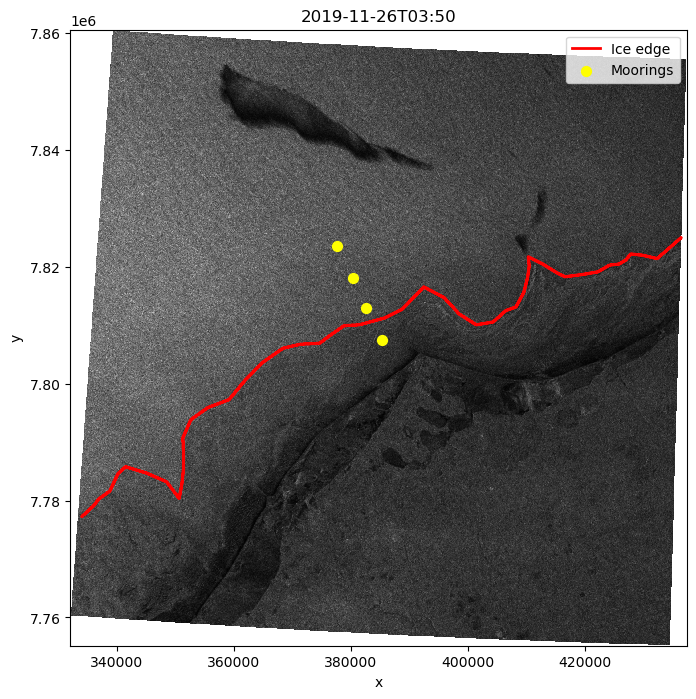

In [40]:
#Plot to Check Work
Nov_26 = SAT_ds.sel(time="2019-11-26", method="nearest")

fig, ax = plt.subplots(figsize=(8, 8))

# SAR image
Nov_26["SAR_backscatter"].plot(ax=ax, cmap="gray", add_colorbar=False)

# Ice edge — plot only where value == 1
ice = Nov_26["ice_edge"].values
if not np.all(np.isnan(ice)):
    ax.contour(
        SAT_ds.x, SAT_ds.y, ice,
        levels=[0.5],
        colors="red",
        linewidths=2,
        zorder=4,
        label="Ice edge"
    )
    ax.plot([], [], color="red", linewidth=2, label="Ice edge")  # legend entry

# Moorings
moor_gdf.plot(ax=ax, color="yellow", markersize=50, zorder=5, label="Moorings")

ax.set_title(str(Nov_26.time.values)[:16])
ax.legend()
plt.show()